# EDA of Fashion Dataset
This notebook performs exploratory data analysis on the fashion product dataset used for the multimodal product search system.

The analysis covers three complementary sources:

- `styles.csv` — tabular product metadata
- `images/` — local product images
- `styles/` — per-product JSON metadata

The goal of this EDA is to understand data quality, relationships between the sources, and which information may be useful for the later visual, textual, and structured retrieval pipeline.

**Note:** EDA findings are documented here; data-cleaning and transformation decisions will be handled separately during the ingestion/preprocessing stage.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_DIR = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset")

STYLES_CSV = DATASET_DIR / "styles.csv"
IMAGES_CSV = DATASET_DIR / "images.csv"
IMAGES_DIR = DATASET_DIR / "images"
STYLES_DIR = DATASET_DIR / "styles"

## 1. `styles.csv` dataset EDA
We first inspect the tabular metadata to establish the basic structure of the catalog before investigating images and JSON metadata.

In [3]:
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')

print("shape:", df.shape)

shape: (44424, 10)


In [4]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [6]:
columns = df.columns.tolist()
columns

['id',
 'gender',
 'masterCategory',
 'subCategory',
 'articleType',
 'baseColour',
 'season',
 'year',
 'usage',
 'productDisplayName']

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,44424.0,NaN,NaN,NaN,29696.334301,17049.490518,1163.0,14768.75,28618.5,44683.25,60000.0
gender,44424,5,Men,22147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
masterCategory,44424,7,Apparel,21397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subCategory,44424,45,Topwear,15402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
articleType,44424,143,Tshirts,7067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
baseColour,44409,46,Black,9728,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,44403,4,Summer,21472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,44423.0,NaN,NaN,NaN,2012.806497,2.12648,2007.0,2011.0,2012.0,2015.0,2019.0
usage,44107,8,Casual,34406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productDisplayName,44417,31121,Lucera Women Silver Earrings,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.nunique().sort_values()

season                    4
gender                    5
masterCategory            7
usage                     8
year                     13
subCategory              45
baseColour               46
articleType             143
productDisplayName    31121
id                    44424
dtype: int64

In [9]:
df.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
dtype: object

In [10]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
usage,317,0.713578
season,21,0.047272
baseColour,15,0.033766
productDisplayName,7,0.015757
year,1,0.002251
id,0,0.000000
gender,0,0.000000
articleType,0,0.000000
masterCategory,0,0.000000
subCategory,0,0.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["id"].duplicated().sum()

np.int64(0)

In [13]:
df["id"].astype(str).str.len().describe()

count    44424.000000
mean         4.839636
std          0.366947
min          4.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: id, dtype: float64

In [14]:
categorical_cols = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "usage"
]

In [15]:
for col in categorical_cols:
    print(f"\n{'=' * 50}")
    print(col)
    print("Unique:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(20))


gender
Unique: 5
gender
Men       22147
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64

masterCategory
Unique: 7
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

subCategory
Unique: 45
subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree               

In [16]:
for col in categorical_cols:
    values = df[col].dropna().astype(str)
    
    print(f"\n{col}")
    print("Leading/trailing whitespace:",
          (values != values.str.strip()).sum())
    print("Unique raw values:", values.nunique())
    print("Unique lowercase values:", values.str.lower().nunique())


gender
Leading/trailing whitespace: 0
Unique raw values: 5
Unique lowercase values: 5

masterCategory
Leading/trailing whitespace: 0
Unique raw values: 7
Unique lowercase values: 7

subCategory
Leading/trailing whitespace: 0
Unique raw values: 45
Unique lowercase values: 45

articleType
Leading/trailing whitespace: 0
Unique raw values: 143
Unique lowercase values: 143

baseColour
Leading/trailing whitespace: 0
Unique raw values: 46
Unique lowercase values: 46

season
Leading/trailing whitespace: 0
Unique raw values: 4
Unique lowercase values: 4

usage
Leading/trailing whitespace: 0
Unique raw values: 8
Unique lowercase values: 8


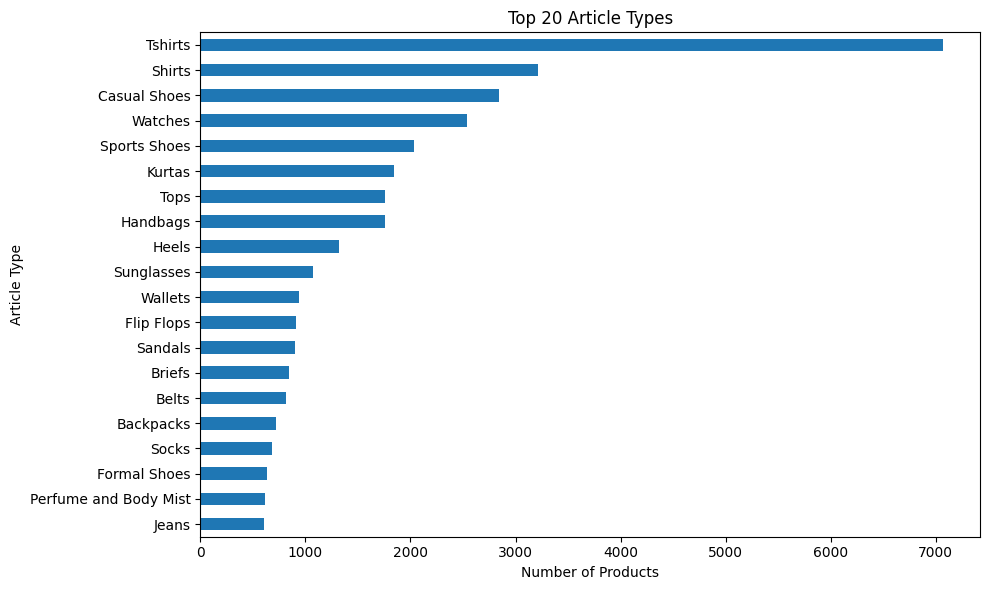

In [17]:
article_counts = df["articleType"].value_counts().head(20)

plt.figure(figsize=(10, 6))
article_counts.sort_values().plot(kind="barh")

plt.title("Top 20 Article Types")
plt.xlabel("Number of Products")
plt.ylabel("Article Type")
plt.tight_layout()
plt.show()

### Category Relationship Checks

The previous distributions show the overall frequency of each categorical field. The following checks examine whether the hierarchy is internally consistent - for example, whether one `articleType` is associated with multiple `subCategory` values or one `subCategory` with multiple `masterCategory` values.


In [18]:
article_sub = df.groupby("articleType")["subCategory"].nunique().sort_values(ascending=False)

article_sub.head(20)

articleType
Wallets                      3
Body Lotion                  2
Backpacks                    2
Shorts                       2
Travel Accessory             2
Mask and Peel                2
Belts                        2
Face Moisturisers            2
Kajal and Eyeliner           2
Face Scrub and Exfoliator    2
Flip Flops                   2
Dresses                      2
Eyeshadow                    2
Clutches                     2
Laptop Bag                   2
Scarves                      2
Ties                         2
Wristbands                   2
Swimwear                     2
Tshirts                      2
Name: subCategory, dtype: int64

In [19]:
sub_master = df.groupby("subCategory")["masterCategory"].nunique().sort_values(ascending=False)

sub_master.head(20)

subCategory
Perfumes              2
Socks                 2
Bags                  1
Apparel Set           1
Accessories           1
Belts                 1
Bottomwear            1
Cufflinks             1
Dress                 1
Eyes                  1
Eyewear               1
Bath and Body         1
Beauty Accessories    1
Fragrance             1
Flip Flops            1
Hair                  1
Free Gifts            1
Home Furnishing       1
Innerwear             1
Jewellery             1
Name: masterCategory, dtype: int64

In [20]:
print("Article types belonging to >1 subcategory:")
print(article_sub[article_sub > 1])

Article types belonging to >1 subcategory:
articleType
Wallets                      3
Body Lotion                  2
Backpacks                    2
Shorts                       2
Travel Accessory             2
Mask and Peel                2
Belts                        2
Face Moisturisers            2
Kajal and Eyeliner           2
Face Scrub and Exfoliator    2
Flip Flops                   2
Dresses                      2
Eyeshadow                    2
Clutches                     2
Laptop Bag                   2
Scarves                      2
Ties                         2
Wristbands                   2
Swimwear                     2
Tshirts                      2
Water Bottle                 2
Messenger Bag                2
Handbags                     2
Perfume and Body Mist        2
Sandals                      2
Name: subCategory, dtype: int64


In [21]:
print("Subcategories belonging to >1 master category:")
print(sub_master[sub_master > 1])

Subcategories belonging to >1 master category:
subCategory
Perfumes    2
Socks       2
Name: masterCategory, dtype: int64


In [22]:
for col in ["masterCategory", "subCategory", "articleType"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== masterCategory =====
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

===== subCategory =====
subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties        

In [23]:
print(df["baseColour"].value_counts(dropna=False))

baseColour
Black                9728
White                5538
Blue                 4918
Brown                3494
Grey                 2741
Red                  2455
Green                2115
Pink                 1860
Navy Blue            1789
Purple               1640
Silver               1090
Yellow                778
Beige                 749
Gold                  628
Maroon                581
Orange                530
Olive                 410
Multi                 394
Cream                 390
Steel                 315
Charcoal              228
Peach                 195
Off White             182
Skin                  179
Lavender              162
Grey Melange          146
Khaki                 139
Magenta               129
Teal                  120
Tan                   114
Mustard                97
Bronze                 95
Copper                 86
Turquoise Blue         69
Rust                   66
Burgundy               45
Metallic               43
Coffee Brown           31
M

In [24]:
df["productDisplayName"].str.len().describe()

count    44417.000000
mean        34.669608
std          8.520417
min          7.000000
25%         29.000000
50%         34.000000
75%         40.000000
max         88.000000
Name: productDisplayName, dtype: float64

In [25]:
df["productDisplayName"].str.split().str.len().describe()

count    44417.000000
mean         5.790868
std          1.403846
min          1.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         14.000000
Name: productDisplayName, dtype: float64

In [26]:
df["productDisplayName"].sample(30, random_state=42).tolist()

['Puma Women Solid Black Jackets',
 'ADIDAS Unisex Black White Headband',
 'Murcia Women Casual Handbag',
 'Urban Yoga Women Printed Purple Kurta',
 'Nike Women As Statement White T-Shirts',
 'New Hide Men Brown Belt',
 'Nike Unisex Federer Blue Cap',
 'Park Avenue Men Grey Briefs',
 'Chromozome Men Grey Melange Trunks',
 'Bwitch Turquiose Blue Nightdress',
 'Puma Women Black Capris',
 'York Women Amazing Perfume',
 'Puma Men Faas 800 Black Sports Shoes',
 'United Colors of Benetton Women Solid Black Wallets',
 'Turtle Men Black Trousers',
 'Fogg Women Radiate Deo',
 'Nike Men Grey Striped T-shirt',
 'Lucera Women Silver Ring',
 'Gini and Jony Girls Kinky Pink Capris',
 'Lomani Women Deo',
 'Revlon Plum Deluxe Nail Enamel 315',
 'Fabindia Women Anusuya Silver Earrings',
 "Inkfruit Men's Star War Black T-shirt",
 'Aneri Women Blue Printed Kurta',
 'Puma Women White Ferrari Wallet',
 'BIBA Women Printed Green Kurta',
 'Mayhem Men Aviator Sunglasses 1024-209',
 'Lovable Women All Day Long

In [27]:
print("Unique product names:", df["productDisplayName"].nunique())
print("Duplicate product names:",
      df["productDisplayName"].duplicated().sum())

Unique product names: 31121
Duplicate product names: 13302


In [28]:
df["productDisplayName"].value_counts().head(20)

productDisplayName
Lucera Women Silver Earrings              82
Lucera Women Silver Pendant               56
Lucera Women Silver Ring                  50
Catwalk Women Black Heels                 48
Q&Q Men Black Dial Watch                  42
Fastrack Men Black Dial Watch             41
Maxima Men White Dial Watch               38
Fabindia Women Anusuya Silver Earrings    37
FNF Multi Coloured Printed Sari           32
Miami Blues Women Sunglasses              31
Coolers Men Black Sandals                 31
Murcia Women Brown Handbag                28
Murcia Women Black Handbag                28
Lucera Women Silver Pendant with Chain    28
Locomotive Men Washed Blue Jeans          27
Idee Men Black Sunglasses                 26
Mark Taylor Men Blue Striped Shirt        26
Titan Men White Dial Watch                26
Red Tape Men Brown Shoes                  26
Revv Men Steel Ring                       26
Name: count, dtype: int64

In [29]:
weird_article_types = article_sub[article_sub > 1].index

df[df["articleType"].isin(weird_article_types)][
    ["articleType", "subCategory", "masterCategory"]
].drop_duplicates().sort_values("articleType")

,articleType,subCategory,masterCategory
6814,Backpacks,Free Gifts,Free Items
145,Backpacks,Bags,Accessories
11,Belts,Belts,Accessories
13713,Belts,Topwear,Apparel
9358,Body Lotion,Skin,Personal Care
6792,Body Lotion,Bath and Body,Personal Care
23765,Clutches,Free Gifts,Free Items
135,Clutches,Bags,Accessories
8304,Dresses,Topwear,Apparel
94,Dresses,Dress,Apparel


In [30]:
weird_subcategories = sub_master[sub_master > 1].index

df[df["subCategory"].isin(weird_subcategories)][
    ["subCategory", "masterCategory", "articleType"]
].drop_duplicates().sort_values("subCategory")

,subCategory,masterCategory,articleType
10171,Perfumes,Personal Care,Perfume and Body Mist
20016,Perfumes,Accessories,Perfume and Body Mist
8,Socks,Accessories,Socks
7177,Socks,Apparel,Booties


In [31]:
name = "Lucera Women Silver Earrings"

df[df["productDisplayName"] == name][
    [
        "id",
        "gender",
        "masterCategory",
        "subCategory",
        "articleType",
        "baseColour",
        "season",
        "year",
        "usage"
    ]
].head(30)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage
1461,48728,Women,Accessories,Jewellery,Earrings,Silver,Summer,2015.0,Casual
1626,48717,Women,Accessories,Jewellery,Earrings,Silver,Summer,2012.0,Casual
2052,48710,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual
2356,48726,Women,Accessories,Jewellery,Earrings,Silver,Summer,2015.0,Casual
2682,48721,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual
4494,48720,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual
4574,48718,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual
5579,48664,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual
6386,48655,Women,Accessories,Jewellery,Earrings,Silver,Summer,2012.0,Casual
6606,48652,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual


In [32]:
df[df["productDisplayName"] == name].nunique()

id                    82
gender                 1
masterCategory         1
subCategory            1
articleType            1
baseColour             1
season                 2
year                   3
usage                  1
productDisplayName     1
dtype: int64

### Remarks

The tabular metadata contains no duplicate rows and the `id` field is unique across the dataset. The main categorical fields are populated, while a small amount of missingness exists in `baseColour`, `season`, `year`, `usage`, and `productDisplayName`.

The category hierarchy is not perfectly one-to-one: a small number of article types occur under multiple subcategories, and a small number of subcategories occur under multiple master categories.

`productDisplayName` is mostly populated and contains useful product-level text, but duplicate names are common, so the display name should not be treated as a unique product identifier.


## 2. Image EDA

The visual modality is central to the planned product-search system, so we verify that product IDs map correctly to local images and inspect image validity, dimensions, formats, visual consistency, and exact duplication.

The dataset also contains an `images.csv` file with `filename` and `link` columns. Since the local `images/` directory is the source used for embedding, the checks below focus on the actual local image files and their relationship with product IDs.


In [33]:
from PIL import Image

### 1. Image <--> product relationship

In [34]:
image_paths = {
    path.stem: path
    for path in IMAGES_DIR.glob("*.jpg")
}

print("Number of JPG files:", len(image_paths))

Number of JPG files: 44441


In [35]:
df["id_str"] = df["id"].astype(str)

df["image_exists"] = df["id_str"].map(image_paths).notna()

print(df["image_exists"].value_counts())

image_exists
True     44419
False        5
Name: count, dtype: int64


In [36]:
print(
    "Products without local image:",
    (~df["image_exists"]).sum()
)

Products without local image: 5


In [37]:
missing_products = df.loc[
    ~df["image_exists"],
    ["id", "productDisplayName", "gender",
     "masterCategory", "subCategory", "articleType"]
]

missing_products

,id,productDisplayName,gender,masterCategory,subCategory,articleType
6695,39403,U.S. Polo Assn. Men Black Tailored Fit Casual ...,Men,Apparel,Topwear,Shirts
16194,39410,U.S. Polo Assn. Men Cream-Coloured Tailored Fi...,Men,Apparel,Topwear,Shirts
32309,39401,U.S. Polo Assn. Denim Co. Men Blue Slim Straig...,Men,Apparel,Bottomwear,Jeans
36381,39425,U.S. Polo Assn. Men Red Polo T-Shirt,Men,Apparel,Topwear,Tshirts
40000,12347,Fastrack Men Red Manhattan Regular Fit Solid F...,Men,Apparel,Topwear,Suits


#### Check JSON Availability for Products Without a Local Image

For products that are present in `styles.csv` but have no local image, we check whether their JSON metadata still exists. This helps distinguish missing image assets from missing product records.


In [38]:
missing_products["json_exists"] = missing_products["id"].apply(
    lambda x: (STYLES_DIR / f"{x}.json").exists()
)

missing_products

,id,productDisplayName,gender,masterCategory,subCategory,articleType,json_exists
6695,39403,U.S. Polo Assn. Men Black Tailored Fit Casual ...,Men,Apparel,Topwear,Shirts,True
16194,39410,U.S. Polo Assn. Men Cream-Coloured Tailored Fi...,Men,Apparel,Topwear,Shirts,True
32309,39401,U.S. Polo Assn. Denim Co. Men Blue Slim Straig...,Men,Apparel,Bottomwear,Jeans,True
36381,39425,U.S. Polo Assn. Men Red Polo T-Shirt,Men,Apparel,Topwear,Tshirts,True
40000,12347,Fastrack Men Red Manhattan Regular Fit Solid F...,Men,Apparel,Topwear,Suits,True


### 2. Check for Orphan Images

An orphan image is a local image whose ID does not appear in `styles.csv`. These records are investigated separately because they may correspond to JSON products that are absent from the CSV.


In [39]:
product_ids = set(df["id_str"])

orphan_images = [
    path for path in IMAGES_DIR.glob("*.jpg")
    if path.stem not in product_ids
]

print("Orphan images:", len(orphan_images))

Orphan images: 22


In [40]:
orphan_df = pd.DataFrame({
    "id": [path.stem for path in orphan_images],
    "path": [str(path) for path in orphan_images]
})

orphan_df

,id,path
0,23111,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,3428,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,44065,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,23108,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,23117,/kaggle/input/datasets/paramaggarwal/fashion-p...
5,23118,/kaggle/input/datasets/paramaggarwal/fashion-p...
6,4854,/kaggle/input/datasets/paramaggarwal/fashion-p...
7,23109,/kaggle/input/datasets/paramaggarwal/fashion-p...
8,23115,/kaggle/input/datasets/paramaggarwal/fashion-p...
9,23110,/kaggle/input/datasets/paramaggarwal/fashion-p...


#### Check JSON Availability for Orphan Images

We check whether orphan image IDs also have JSON metadata. This helps establish whether the discrepancy is isolated to `styles.csv` or affects the other dataset sources as well.


In [41]:
orphan_df["json_exists"] = orphan_df["id"].apply(
    lambda x: (STYLES_DIR / f"{x}.json").exists()
)

orphan_df

,id,path,json_exists
0,23111,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
1,3428,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
2,44065,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
3,23108,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
4,23117,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
5,23118,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
6,4854,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
7,23109,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
8,23115,/kaggle/input/datasets/paramaggarwal/fashion-p...,True
9,23110,/kaggle/input/datasets/paramaggarwal/fashion-p...,True


### 3. Check Image Readability

Images are opened with PIL to verify that they can actually be decoded and to collect basic technical properties such as dimensions, format, and color mode.


In [42]:
image_records = []

for product_id, path in image_paths.items():
    try:
        with Image.open(path) as img:
            image_records.append({
                "id": product_id,
                "path": str(path),
                "width": img.width,
                "height": img.height,
                "format": img.format,
                "mode": img.mode,
                "file_size_kb": path.stat().st_size / 1024,
                "valid": True
            })
    except Exception as e:
        image_records.append({
            "id": product_id,
            "path": str(path),
            "valid": False,
            "error": str(e)
        })

image_df = pd.DataFrame(image_records)

print(image_df["valid"].value_counts())

valid
True    44441
Name: count, dtype: int64


### 4. Inspect Image Dimensions

We inspect width, height, and aspect ratio distributions. This helps identify whether the catalog images follow a consistent presentation format and whether unusual dimensions may require special preprocessing.


In [43]:
image_df[["width", "height"]].describe()

,width,height
count,44441.000000,44441.000000
mean,1397.141221,1862.873518
std,367.209807,489.965352
min,150.000000,200.000000
25%,1080.000000,1440.000000
50%,1080.000000,1440.000000
75%,1800.000000,2400.000000
max,3744.000000,5616.000000


In [44]:
image_df["aspect_ratio"] = (
    image_df["width"] / image_df["height"]
)

In [45]:
image_df["aspect_ratio"].describe()

count    44441.000000
mean         0.750009
std          0.003007
min          0.664179
25%          0.750000
50%          0.750000
75%          0.750000
max          1.000000
Name: aspect_ratio, dtype: float64

In [46]:
image_df.groupby(
    ["width", "height"]
).size().sort_values(ascending=False).head(20)

width  height
1080   1440      24459
1800   2400      19721
150    200         119
360    480          60
540    720          21
1200   1600          8
2700   2700          4
2250   3000          4
3744   5616          3
1799   2400          2
2355   3140          2
1800   2401          2
3456   5184          2
2425   3233          2
1800   2297          2
2759   3678          2
800    800           1
683    1024          1
480    640           1
514    644           1
dtype: int64

### 5. Visualise Aspect Ratios

A histogram is used to visualize the aspect-ratio distribution and make unusually shaped images easier to identify.


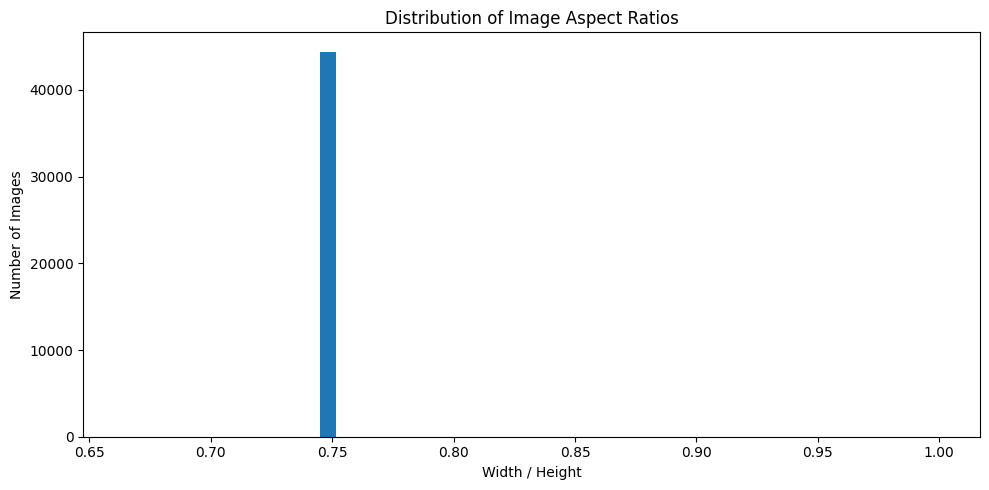

In [47]:
plt.figure(figsize=(10, 5))

plt.hist(
    image_df["aspect_ratio"],
    bins=50
)

plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Aspect Ratios")

plt.tight_layout()
plt.show()

### 6. Check Image File Sizes

File-size statistics help identify unusually small or large files that may indicate corrupted, low-quality, or otherwise atypical image assets.


In [48]:
image_df["file_size_kb"].describe()

count    44441.000000
mean       327.850014
std        180.428208
min          2.663086
25%        228.236328
50%        306.283203
75%        370.137695
max       4582.351562
Name: file_size_kb, dtype: float64

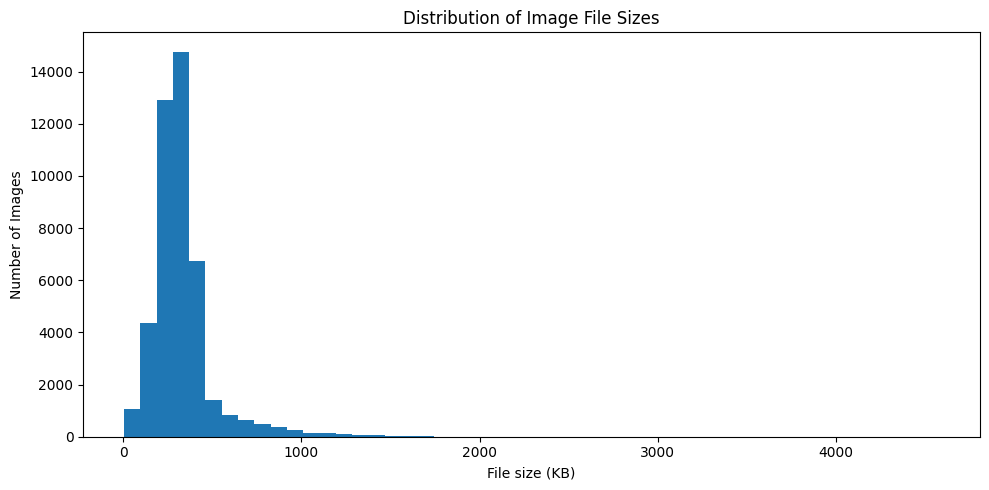

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(
    image_df["file_size_kb"],
    bins=50
)

plt.xlabel("File size (KB)")
plt.ylabel("Number of Images")
plt.title("Distribution of Image File Sizes")

plt.tight_layout()
plt.show()

#### Inspect Image-Size Outliers

The smallest and largest files are inspected as potential outliers. An unusual file size is not automatically an error, so these records are treated as candidates for investigation rather than automatically removed.


In [50]:
image_df.nsmallest(
    20, "file_size_kb"
)[
    ["id", "width", "height", "file_size_kb"]
]

,id,width,height,file_size_kb
25620,8768,150,200,2.663086
31775,3213,150,200,2.872070
16881,11259,150,200,2.899414
1712,15853,150,200,2.938477
41824,16080,150,200,2.948242
14364,15859,150,200,2.958008
14871,15869,150,200,2.974609
2819,15856,150,200,3.004883
27793,3629,150,200,3.039062
22910,16083,150,200,3.057617


In [51]:
image_df.nlargest(
    20, "file_size_kb"
)[
    ["id", "width", "height", "file_size_kb"]
]

,id,width,height,file_size_kb
42489,28492,3744,5616,4582.351562
1717,25958,3744,5616,4124.465820
692,25943,3744,5616,2849.062500
32617,2135,1800,2400,2305.699219
32067,2127,1800,2400,2111.828125
42176,33540,1800,2400,2008.801758
13630,2574,1800,2400,2003.668945
2074,1936,1800,2400,1995.055664
20967,2985,1800,2400,1984.136719
39911,33238,1800,2400,1947.990234


### 7. Check Image Formats and Modes

We inspect the image format and color mode to determine whether the dataset contains a consistent image representation that can be passed through the later image preprocessing pipeline.


In [52]:
print(image_df["format"].value_counts())

format
JPEG    44441
Name: count, dtype: int64


In [53]:
print(image_df["mode"].value_counts())

mode
RGB    44441
Name: count, dtype: int64


### 8. Inspect Sample Images

A random sample of product images is displayed to visually verify that the images correspond to catalog products and to look for obvious issues such as irrelevant images, severe cropping, multiple products, or inconsistent backgrounds.

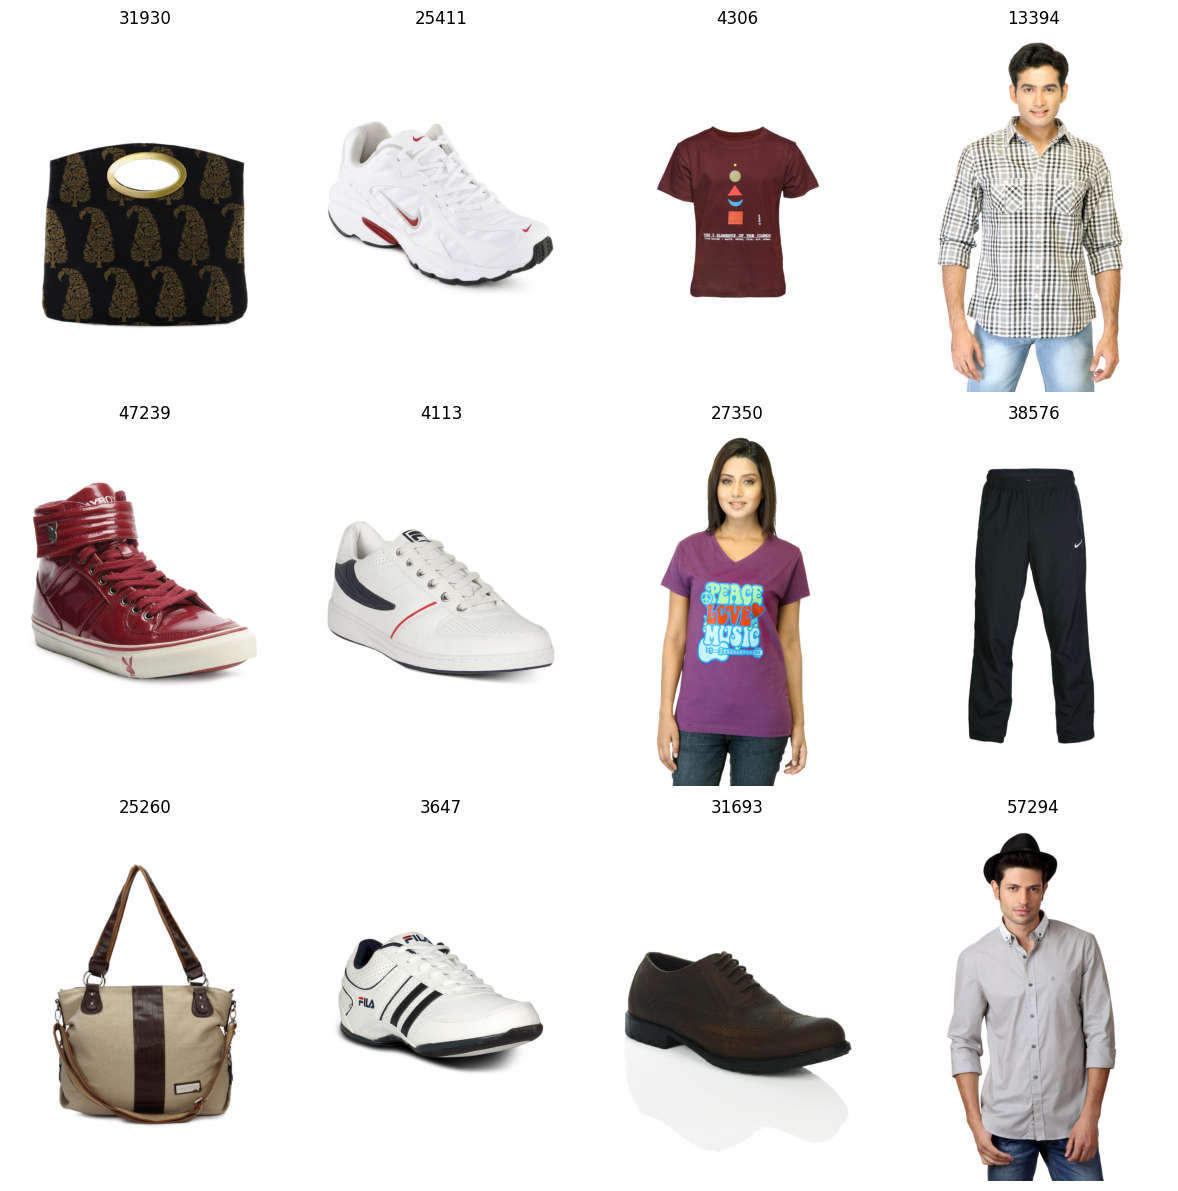

In [54]:
sample_ids = df["id"].sample(12, random_state=10)

fig, axes = plt.subplots(3, 4, figsize=(12, 12))

for ax, product_id in zip(axes.flat, sample_ids):
    path = image_paths[str(product_id)]
    
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(str(product_id))
    ax.axis("off")

plt.tight_layout()
plt.show()

### 9. Check for Exact Duplicate Images

File hashes are used to identify byte-identical image files. Duplicate images are important to identify because multiple product IDs may share the same visual asset, which can affect retrieval evaluation and the interpretation of product-level embeddings.


In [55]:
import hashlib

def file_hash(path):
    h = hashlib.md5()
    
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    
    return h.hexdigest()

In [56]:
image_df["file_hash"] = image_df["path"].apply(file_hash)

In [57]:
duplicate_hashes = (
    image_df["file_hash"]
    .value_counts()
)

duplicate_hashes = duplicate_hashes[
    duplicate_hashes > 1
]

print("Number of duplicated image hashes:", len(duplicate_hashes))
print("Images involved:", duplicate_hashes.sum())

Number of duplicated image hashes: 652
Images involved: 1431


In [58]:
duplicated_hashes = duplicate_hashes.index

image_df[
    image_df["file_hash"].isin(duplicated_hashes)
].sort_values("file_hash").head(30)

,id,path,width,height,format,mode,file_size_kb,valid,aspect_ratio,file_hash
6217,8384,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,336.354492,True,0.75,01358f61f95dd17301ef5722a1955955
18026,8385,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,336.354492,True,0.75,01358f61f95dd17301ef5722a1955955
26741,8332,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,329.416992,True,0.75,01d941ef6764bd82fe4591f5d739097b
41325,8333,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,329.416992,True,0.75,01d941ef6764bd82fe4591f5d739097b
32966,13872,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,370.953125,True,0.75,02403956e770a5a8d8c754203c6cd97a
19697,13873,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,370.953125,True,0.75,02403956e770a5a8d8c754203c6cd97a
8130,13887,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,353.833008,True,0.75,02c880e5890321a901bf3e093073d62d
16727,13886,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,353.833008,True,0.75,02c880e5890321a901bf3e093073d62d
35353,41977,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,385.224609,True,0.75,02cf58b7ac787f364ca86d61237e8342
11267,40155,/kaggle/input/datasets/paramaggarwal/fashion-p...,1800,2400,JPEG,RGB,385.224609,True,0.75,02cf58b7ac787f364ca86d61237e8342


In [59]:
duplicate_groups = (
    image_df[image_df["file_hash"].isin(duplicated_hashes)]
    .groupby("file_hash")
    .size()
)

duplicate_groups.value_counts().sort_index()

2    528
3    121
4      3
Name: count, dtype: int64

In [60]:
sample_hashes = duplicate_groups.head(10).index

duplicate_examples = image_df[
    image_df["file_hash"].isin(sample_hashes)
][["id", "file_hash"]].copy()

duplicate_examples["id"] = duplicate_examples["id"].astype(int)

duplicate_examples.merge(
    df[
        ["id", "productDisplayName",
         "gender", "masterCategory",
         "subCategory", "articleType"]
    ],
    on="id",
    how="left"
).sort_values("file_hash")

,id,file_hash,productDisplayName,gender,masterCategory,subCategory,articleType
10,8385,01358f61f95dd17301ef5722a1955955,Doodle Girl's Hippie Chic Orange Teen Kidswear,Girls,Apparel,Topwear,Tshirts
1,8384,01358f61f95dd17301ef5722a1955955,Doodle Girl's Hippie Chic Orange Kidswear,Girls,Apparel,Topwear,Tshirts
18,8333,01d941ef6764bd82fe4591f5d739097b,Doodle Boy's Car Print White Red Blue Teen Kid...,Boys,Apparel,Topwear,Tshirts
13,8332,01d941ef6764bd82fe4591f5d739097b,Doodle Boy's Car Print White Red Blue Kidswear,Boys,Apparel,Topwear,Tshirts
16,13872,02403956e770a5a8d8c754203c6cd97a,Scullers Men Solid Purple Shirts,Men,Apparel,Topwear,Shirts
12,13873,02403956e770a5a8d8c754203c6cd97a,Scullers Men Solid Purple Shirts,Men,Apparel,Topwear,Shirts
4,13887,02c880e5890321a901bf3e093073d62d,Scullers Men Check Black Shirts,Men,Apparel,Topwear,Shirts
9,13886,02c880e5890321a901bf3e093073d62d,Scullers Men Check Black Shirts,Men,Apparel,Topwear,Shirts
5,40155,02cf58b7ac787f364ca86d61237e8342,Gini and Jony Boys Beach White Shorts,Boys,Apparel,Bottomwear,Shorts
17,41977,02cf58b7ac787f364ca86d61237e8342,Gini and Jony Boys Beach White Shorts,Boys,Apparel,Bottomwear,Shorts


### 10. Getting more info on missing and orphan products

In [61]:
images_df = pd.read_csv(IMAGES_CSV)

print(images_df.columns.tolist())
images_df.head()

['filename', 'link']


,filename,link
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...


In [62]:
images_df["id"] = (
    images_df["filename"]
    .str.replace(".jpg", "", regex=False)
    .astype(int)
)

In [63]:
images_df[images_df["id"].isin(missing_products["id"])]

,filename,link,id
6697,39403.jpg,undefined,39403
16207,39410.jpg,undefined,39410
32324,39401.jpg,undefined,39401
36399,39425.jpg,undefined,39425
40022,12347.jpg,undefined,12347


In [64]:
orphan_ids = orphan_df["id"].astype(int)

images_df[images_df["id"].isin(orphan_ids)]

,filename,link,id
6042,44065.jpg,http://assets.myntassets.com/v1/images/style/p...,44065
6567,3413.jpg,http://assets.myntassets.com/v1/images/style/p...,3413
7397,23101.jpg,http://assets.myntassets.com/v1/images/style/p...,23101
7937,23108.jpg,http://assets.myntassets.com/v1/images/style/p...,23108
9024,4854.jpg,http://assets.myntassets.com/v1/images/style/p...,4854
10262,23109.jpg,http://assets.myntassets.com/v1/images/style/p...,23109
10425,23100.jpg,http://assets.myntassets.com/v1/images/style/p...,23100
10903,23107.jpg,http://assets.myntassets.com/v1/images/style/p...,23107
11371,59768.jpg,http://assets.myntassets.com/v1/images/style/p...,59768
11943,23114.jpg,http://assets.myntassets.com/v1/images/style/p...,23114


In [65]:
orphan_json_paths = [
    STYLES_DIR / f"{x}.json"
    for x in orphan_ids
]

[x.name for x in orphan_json_paths if x.exists()]

['23111.json',
 '3428.json',
 '44065.json',
 '23108.json',
 '23117.json',
 '23118.json',
 '4854.json',
 '23109.json',
 '23115.json',
 '23110.json',
 '23124.json',
 '3418.json',
 '23103.json',
 '23112.json',
 '23114.json',
 '23101.json',
 '23107.json',
 '23100.json',
 '3413.json',
 '59768.json',
 '23116.json',
 '23127.json']

### Image EDA Summary

The image collection is largely consistent and suitable for visual
embedding. Most products have a corresponding local image, the images are
valid JPEG/RGB files, and their dimensions are predominantly standardized.

A small number of products have missing local images, while 22 images are
not represented in `styles.csv`. Exact duplicate images occur across
multiple product IDs. These cases will be handled explicitly during the
data-ingestion and evaluation stages rather than being silently removed
during EDA.

## 3. JSON Metadata EDA

Each product has a JSON record under `styles/`. The JSON contains response-level metadata and a richer `data` object with product information, descriptions, article attributes, image views, and catalog information.

This section evaluates JSON availability, schema variability, field completeness, useful nested structures, and consistency with `styles.csv`.


### 1. JSON Availability and Validity

We first compare the JSON files with the product IDs in `styles.csv`, then verify that the JSON files can be parsed successfully.


In [66]:
import json

In [67]:
json_paths = list(STYLES_DIR.glob("*.json"))

print("Number of JSON files:", len(json_paths))

Number of JSON files: 44446


In [68]:
json_ids = {path.stem for path in json_paths}
csv_ids = set(df["id"].astype(str))

print("JSON files:", len(json_ids))
print("IDs present in both:", len(json_ids & csv_ids))
print("JSON IDs absent from styles.csv:", len(json_ids - csv_ids))
print("styles.csv IDs absent from JSON:", len(csv_ids - json_ids))

JSON files: 44446
IDs present in both: 44424
JSON IDs absent from styles.csv: 22
styles.csv IDs absent from JSON: 0


### 2. Check whether JSON files are valid

In [69]:
json_records = []
invalid_json = []

for path in json_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        json_records.append(data)
        
    except Exception as e:
        invalid_json.append({
            "path": str(path),
            "error": str(e)
        })

print("Valid JSON files:", len(json_records))
print("Invalid JSON files:", len(invalid_json))

Valid JSON files: 44446
Invalid JSON files: 0


### 3. JSON schema

In [70]:
sample_id = str(df["id"].iloc[0])

sample_path = STYLES_DIR / f"{sample_id}.json"

with open(sample_path, "r", encoding="utf-8") as f:
    sample_json = json.load(f)

print(sample_json.keys())

for key, value in sample_json.items():
    print(key, "->", type(value).__name__)

print("\nDATA KEYS:")
print(sample_json["data"].keys())
print()

for key, value in sample_json["data"].items():
    print(key, "->", type(value).__name__)

dict_keys(['notification', 'meta', 'data'])
notification -> dict
meta -> dict
data -> dict

DATA KEYS:
dict_keys(['id', 'price', 'discountedPrice', 'styleType', 'productTypeId', 'articleNumber', 'visualTag', 'productDisplayName', 'variantName', 'myntraRating', 'catalogAddDate', 'brandName', 'ageGroup', 'gender', 'baseColour', 'colour1', 'colour2', 'fashionType', 'season', 'year', 'usage', 'vat', 'displayCategories', 'weight', 'navigationId', 'landingPageUrl', 'articleAttributes', 'crossLinks', 'brandUserProfile', 'codEnabled', 'styleImages', 'lookGoodAlbum', 'style360Images', 'masterCategory', 'subCategory', 'articleType', 'isEMIEnabled', 'otherFlags', 'articleDisplayAttr', 'productDescriptors', 'styleOptions'])

id -> int
price -> int
discountedPrice -> int
styleType -> str
productTypeId -> int
articleNumber -> str
visualTag -> str
productDisplayName -> str
variantName -> str
myntraRating -> int
catalogAddDate -> int
brandName -> str
ageGroup -> str
gender -> str
baseColour -> str
col

In [71]:
print("NOTIFICATION")
print(sample_json["notification"])

print("\nMETA")
print(sample_json["meta"])

NOTIFICATION
{}

META
{'code': 200, 'requestId': '246fba09-2d88-487c-9cba-9288acc9e121'}


In [72]:
from collections import Counter

data_key_sets = Counter()

for data in json_records:
    keys = tuple(sorted(data.get("data", {}).keys()))
    data_key_sets[keys] += 1

print("Number of unique data schemas:", len(data_key_sets))

for keys, count in data_key_sets.most_common():
    print("\nCount:", count)
    print(keys)

Number of unique data schemas: 24

Count: 17872
('ageGroup', 'articleAttributes', 'articleDisplayAttr', 'articleNumber', 'articleType', 'baseColour', 'brandName', 'brandUserProfile', 'catalogAddDate', 'codEnabled', 'colour1', 'colour2', 'crossLinks', 'discountedPrice', 'displayCategories', 'fashionType', 'gender', 'id', 'isEMIEnabled', 'landingPageUrl', 'lookGoodAlbum', 'masterCategory', 'myntraRating', 'navigationId', 'otherFlags', 'price', 'productDescriptors', 'productDisplayName', 'productTypeId', 'season', 'style360Images', 'styleImages', 'styleOptions', 'styleType', 'subCategory', 'usage', 'variantName', 'vat', 'visualTag', 'weight', 'year')

Count: 12227
('ageGroup', 'articleAttributes', 'articleDisplayAttr', 'articleNumber', 'articleType', 'baseColour', 'brandName', 'brandUserProfile', 'catalogAddDate', 'codEnabled', 'colour1', 'colour2', 'colours', 'crossLinks', 'discountedPrice', 'displayCategories', 'fashionType', 'gender', 'id', 'isEMIEnabled', 'landingPageUrl', 'lookGoodAl

### 3. Measure Field Coverage

For each field under `data`, we measure how often a non-empty value is present. This distinguishes highly reliable product metadata from optional or sparse catalog fields.


In [73]:
json_field_counts = Counter()

for data in json_records:
    product_data = data.get("data", {})

    for field, value in product_data.items():
        if value not in [None, "", {}, []]:
            json_field_counts[field] += 1

json_field_coverage = pd.DataFrame({
    "populated_count": json_field_counts
})

json_field_coverage["coverage_percentage"] = (
    json_field_coverage["populated_count"]
    / len(json_records)
    * 100
)

json_field_coverage.sort_values(
    "coverage_percentage",
    ascending=False
)

,populated_count,coverage_percentage
id,44446,100.000000
price,44446,100.000000
discountedPrice,44446,100.000000
styleType,44446,100.000000
productTypeId,44446,100.000000
articleNumber,44446,100.000000
productDisplayName,44446,100.000000
variantName,44446,100.000000
myntraRating,44446,100.000000
catalogAddDate,44446,100.000000


### 4. Classify Fields

The JSON contains scalar values as well as nested dictionaries and lists. Understanding these types is useful before deciding how each field should be represented in the later canonical product schema.


In [74]:
field_types = []

sample_data = sample_json["data"]

for field, value in sample_data.items():
    field_types.append({
        "field": field,
        "type": type(value).__name__
    })

field_types_df = pd.DataFrame(field_types)

field_types_df

,field,type
0,id,int
1,price,int
2,discountedPrice,int
3,styleType,str
4,productTypeId,int
5,articleNumber,str
6,visualTag,str
7,productDisplayName,str
8,variantName,str
9,myntraRating,int


### 5. Investigate Important Flat Fields

The following fields are reviewed as potential sources of searchable metadata, filtering information, or product-display information.

In [75]:
flat_fields = [
    "id",
    "price",
    "discountedPrice",
    "styleType",
    "productTypeId",
    "articleNumber",
    "visualTag",
    "productDisplayName",
    "variantName",
    "myntraRating",
    "catalogAddDate",
    "brandName",
    "ageGroup",
    "gender",
    "baseColour",
    "colour1",
    "colour2",
    "fashionType",
    "season",
    "year",
    "usage",
    "displayCategories",
    "weight",
    "navigationId",
    "landingPageUrl",
    "codEnabled",
    "masterCategory",
    "subCategory",
    "articleType",
]

In [76]:
for field in flat_fields:
    count = json_field_counts.get(field, 0)
    percentage = count / len(json_records) * 100
    
    print(
        f"{field:25} "
        f"{count:6} "
        f"{percentage:7.2f}%"
    )

id                         44446  100.00%
price                      44446  100.00%
discountedPrice            44446  100.00%
styleType                  44446  100.00%
productTypeId              44446  100.00%
articleNumber              44446  100.00%
visualTag                   1268    2.85%
productDisplayName         44446  100.00%
variantName                44446  100.00%
myntraRating               44446  100.00%
catalogAddDate             44446  100.00%
brandName                  44446  100.00%
ageGroup                   44445  100.00%
gender                     44446  100.00%
baseColour                 44446  100.00%
colour1                    35461   79.78%
colour2                    32557   73.25%
fashionType                44443   99.99%
season                     44425   99.95%
year                       44445  100.00%
usage                      44445  100.00%
displayCategories          38654   86.97%
weight                     44446  100.00%
navigationId               44446  

### 6. `articleAttributes` Analysis

`articleAttributes` contains fine-grained fashion properties such as pattern, fabric, sleeve length, occasion, and other category-specific attributes.

We examine their coverage and value distributions to identify attributes that may provide useful retrieval or filtering signals.


In [77]:
article_attribute_keys = Counter()

for data in json_records:
    product_data = data.get("data", {})
    attrs = product_data.get("articleAttributes", {})

    if isinstance(attrs, dict):
        article_attribute_keys.update(attrs.keys())

pd.DataFrame(
    article_attribute_keys.items(),
    columns=["attribute", "count"]
).sort_values(
    "count",
    ascending=False
)

,attribute,count
13,Body or Garment Size,19035
12,Pattern,16502
20,Fabric,15592
14,Sleeve Length,12836
2,Occasion,11002
...,...,...
194,Number of ID Card Holder,2
195,Coin Pocket Type,2
59,Plating,1
190,Number of Contents,1


In [78]:
attribute_values = {}

for data in json_records:
    product_data = data.get("data", {})
    attrs = product_data.get("articleAttributes", {})

    if not isinstance(attrs, dict):
        continue

    for attribute, value in attrs.items():
        if attribute not in attribute_values:
            attribute_values[attribute] = []

        attribute_values[attribute].append(value)

attribute_stats = []

for attribute, values in attribute_values.items():
    non_null_values = [
        v for v in values
        if v not in [None, ""]
    ]

    attribute_stats.append({
        "attribute": attribute,
        "count": len(non_null_values),
        "coverage_%": len(non_null_values) / len(json_records) * 100,
        "unique_values": len(set(non_null_values))
    })

attribute_stats_df = pd.DataFrame(attribute_stats)

attribute_stats_df.sort_values(
    "count",
    ascending=False
)

,attribute,count,coverage_%,unique_values
13,Body or Garment Size,19035,42.827251,2
12,Pattern,16502,37.128201,16
20,Fabric,15592,35.080772,24
14,Sleeve Length,12836,28.879989,5
2,Occasion,11002,24.753634,16
...,...,...,...,...
194,Number of ID Card Holder,2,0.004500,2
195,Coin Pocket Type,2,0.004500,1
59,Plating,1,0.002250,1
190,Number of Contents,1,0.002250,1


In [79]:
attribute_stats_df.sort_values(
    "count",
    ascending=False
).head(10)

,attribute,count,coverage_%,unique_values
13,Body or Garment Size,19035,42.827251,2
12,Pattern,16502,37.128201,16
20,Fabric,15592,35.080772,24
14,Sleeve Length,12836,28.879989,5
2,Occasion,11002,24.753634,16
0,Type,10207,22.964946,125
45,Fit,10086,22.692706,12
11,Neck,9345,21.025514,23
22,Fabric 2,5291,11.904333,12
41,Material,5120,11.519597,21


### 7. `styleImages` Analysis

The JSON contains multiple image views for many products, including `default`, `search`, `front`, `back`, `left`, and `right`.

We inspect their availability and structure to understand the visual data available for later CLIP-based embedding. The presence of multiple views does not by itself imply that every view should be embedded.


In [80]:
image_variant_counts = Counter()

for data in json_records:
    product_data = data.get("data", {})
    style_images = product_data.get("styleImages", {})

    if isinstance(style_images, dict):
        image_variant_counts.update(style_images.keys())

pd.DataFrame(
    image_variant_counts.items(),
    columns=["image_variant", "count"]
).sort_values(
    "count",
    ascending=False
)

,image_variant,count
0,default,44441
2,search,44441
5,front,41655
3,back,39444
6,right,34085
1,size_representation,30874
4,left,30066
7,top,16857


In [81]:
sample_data["styleImages"]

{'default': {'imageURL': 'http://assets.myntassets.com/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
  'resolutions': {'1080X1440Xmini': 'http://assets.myntassets.com/h_1440,q_95,w_1080/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images_mini.jpg',
   '48X64': 'http://assets.myntassets.com/h_64,q_95,w_48/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
   '1080X1440': 'http://assets.myntassets.com/h_1440,q_95,w_1080/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
   '150X200': 'http://assets.myntassets.com/h_200,q_95,w_150/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
   '360X480': 'http://assets.myntassets.com/h_480,q_95,w_360/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
   '180X240': 'http://assets.myntassets.com/h_240,q_95,w_180/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg',
   '360X480Xmini': 'http://assets.mynta

In [82]:
style_images = sample_data["styleImages"]

print("Variants:")
print(style_images.keys())

for variant, value in style_images.items():
    print("\n", variant)
    print(type(value).__name__)
    
    if isinstance(value, dict):
        print(value.keys())

Variants:
dict_keys(['default', 'size_representation', 'search', 'back', 'left', 'front', 'right'])

 default
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])

 size_representation
str

 search
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])

 back
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])

 left
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])

 front
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])

 right
dict
dict_keys(['imageURL', 'resolutions', 'imageType'])


In [83]:
for variant, value in style_images.items():
    print("\n====================")
    print(variant)
    print("====================")
    
    if isinstance(value, dict):
        for key, val in value.items():
            if isinstance(val, (str, int, float, bool, type(None))):
                print(f"{key}: {val}")
            else:
                print(f"{key}: {type(val).__name__}")


default
imageURL: http://assets.myntassets.com/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg
resolutions: dict
imageType: default

size_representation

search
imageURL: http://assets.myntassets.com/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg
resolutions: dict
imageType: search

back
imageURL: http://assets.myntassets.com/v1/images/style/properties/81948db61589c177d3e2b44a38628e5f_images.jpg
resolutions: dict
imageType: back

left
imageURL: http://assets.myntassets.com/v1/images/style/properties/63b7871d6fd991989878bcde0e2a1d36_images.jpg
resolutions: dict
imageType: left

front
imageURL: http://assets.myntassets.com/v1/images/style/properties/98d4d8ff4f264ca568ba948a4524c92f_images.jpg
resolutions: dict
imageType: front

right
imageURL: http://assets.myntassets.com/v1/images/style/properties/dd2161894546334d85fa603364e6ebd1_images.jpg
resolutions: dict
imageType: right


### 8. `productDescriptors` Analysis

Product descriptors provide additional textual information beyond `productDisplayName`. We inspect descriptor types, coverage, length, and formatting because these fields may contribute useful information to lexical retrieval.


In [84]:
descriptor_keys = Counter()

for data in json_records:
    product_data = data.get("data", {})
    descriptors = product_data.get("productDescriptors", {})

    if isinstance(descriptors, dict):
        descriptor_keys.update(descriptors.keys())

pd.DataFrame(
    descriptor_keys.items(),
    columns=["descriptor", "count"]
).sort_values(
    "count",
    ascending=False
)

,descriptor,count
0,description,44381
2,style_note,16539
1,materials_care_desc,15040
3,size_fit_desc,14228


In [85]:
sample_data["productDescriptors"]

{'description': {'descriptorType': 'description',
  'value': '<p style="text-align: justify;"><strong>Composition</strong><br />Dark brown and indigo blue plaid check shirt with white accents, made of 100% cotton, has long sleeves with buttoned cuffs and a button on the elbow for rolling up the sleeve, denim spread collar, buttoned front placket, patch pocket on the upper left chest and a curved hemline<br /><br /><strong>Fitting</strong><br />Slim<br /><br /><strong>Wash care</strong><br />Machine wash cold at 30 degrees with like colours<br />Do not bleach <br />Wash and dry inside out<br />Hang to dry in shade<br />Medium iron<br /><br />The cleverly mitired pocket on the upper left chest and denim collar adds smooth styling to this dark brown and indigo blue plaid check shirt from turtle, while the cotton fabric keeps you feeling fresh and comfortable all day. Part of the proceeds from the sale of this product go towards the Save Turtle project in collaboration with WWF and Wildlif

### 9. Text Descriptor Analysis

The descriptor fields are analyzed separately because they differ substantially in coverage and length. This helps determine which text fields contain enough useful information to consider during later retrieval preprocessing.


#### 1. Coverage and Text Length

For each descriptor type, we measure the number of populated records and the distribution of text length.


In [86]:
descriptor_fields = [
    "description",
    "style_note",
    "materials_care_desc",
    "size_fit_desc"
]

descriptor_stats = []

for field in descriptor_fields:
    texts = []

    for data in json_records:
        product_data = data.get("data", {})
        descriptors = product_data.get("productDescriptors", {})

        if not isinstance(descriptors, dict):
            continue

        descriptor = descriptors.get(field)

        if isinstance(descriptor, dict):
            text = descriptor.get("value")
        else:
            text = None

        if isinstance(text, str) and text.strip():
            texts.append(text.strip())

    lengths = pd.Series([len(text) for text in texts])

    descriptor_stats.append({
        "field": field,
        "count": len(texts),
        "coverage_%": len(texts) / len(json_records) * 100,
        "mean_chars": lengths.mean() if len(lengths) else 0,
        "median_chars": lengths.median() if len(lengths) else 0,
        "min_chars": lengths.min() if len(lengths) else 0,
        "max_chars": lengths.max() if len(lengths) else 0
    })

descriptor_stats_df = pd.DataFrame(descriptor_stats)

descriptor_stats_df

,field,count,coverage_%,mean_chars,median_chars,min_chars,max_chars
0,description,44381,99.853755,747.298731,762.0,1,55260
1,style_note,16539,37.211448,207.516053,213.0,7,1865
2,materials_care_desc,15040,33.838816,68.148604,56.0,5,1081
3,size_fit_desc,14228,32.011880,45.481304,31.0,2,1258


#### 2. Quantify HTML Formatting

The descriptor values frequently contain HTML markup. We measure how common this is so that HTML-to-text normalization can be accounted for during later preprocessing.


In [87]:
import re

html_stats = []

for field in descriptor_fields:
    total = 0
    html_count = 0

    for data in json_records:
        product_data = data.get("data", {})
        descriptors = product_data.get("productDescriptors", {})

        if not isinstance(descriptors, dict):
            continue

        descriptor = descriptors.get(field)

        if not isinstance(descriptor, dict):
            continue

        text = descriptor.get("value")

        if not isinstance(text, str) or not text.strip():
            continue

        total += 1

        if re.search(r"<[^>]+>", text):
            html_count += 1

    html_stats.append({
        "field": field,
        "text_count": total,
        "contains_html": html_count,
        "html_%": html_count / total * 100 if total else 0
    })

pd.DataFrame(html_stats)

,field,text_count,contains_html,html_%
0,description,44381,42589,95.962236
1,style_note,16539,14313,86.540903
2,materials_care_desc,15040,15015,99.833777
3,size_fit_desc,14228,12918,90.792803


#### 3. Inspect Representative Descriptions

A small number of raw descriptions are inspected to understand the kinds of product information they contain, such as materials, construction, fit, features, styling notes, and care instructions.


In [88]:
samples = []

for data in json_records:
    product_data = data.get("data", {})
    descriptors = product_data.get("productDescriptors", {})

    descriptor = descriptors.get("description")

    if isinstance(descriptor, dict) and descriptor.get("value"):
        samples.append(descriptor["value"])

    if len(samples) == 5:
        break

for text in samples:
    print(text[:1000])
    print("\n" + "=" * 80 + "\n")

-


<p><strong>Style Note</strong><br />A perfect blend of fashion and comfort, the fila Zoom Hi makes for a great casual shoe, with its low profile silhouette and modern design updates.<br /><br /><strong>Product Details</strong><br />Blunt toed synthetic upper with central lace-ups and a Velcro strap above the tongue<br />Padded mesh inner with branding at the tongue and heel<br />Thick TPU outsole with branded grooves, upraised at the heel<br /><br /><strong>Material and Care</strong><br />Synthetic<br />Wipe with a clean damp cloth to remove dust<br />Do not store in sunlight</p>


<p style="text-align: justify;">Win those winning baskets in style with these fila DLS Game Basketball shoes. With a simple-yet-stylish design, enriched with DLS foam cushioning and a grippy outsole, it&rsquo;s designed to bring out the winner in you.<br /><br /><strong>Upper</strong><br />Synthetic leather upper with perforations for absolute durability, breathable comfort and style<br />High ankle coll

#### 4. Description Length Distribution

The description length distribution is examined for skew and extreme outliers. This is relevant to later text preprocessing, but no truncation or filtering decision is made during EDA.


In [89]:
# Reuse the texts collected for description
description_lengths = []

for data in json_records:
    product_data = data.get("data", {})
    descriptors = product_data.get("productDescriptors", {})

    descriptor = descriptors.get("description")

    if isinstance(descriptor, dict):
        text = descriptor.get("value")

        if isinstance(text, str) and text.strip():
            description_lengths.append(len(text))

description_lengths = pd.Series(description_lengths)

description_lengths.describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
)

count    44381.000000
mean       747.300151
std        634.476290
min          1.000000
50%        762.000000
90%       1261.000000
95%       1509.000000
99%       2715.400000
99.5%     3269.300000
max      55260.000000
dtype: float64

In [90]:
description_lengths.sort_values(
    ascending=False
).head(20)

44071    55260
19560    28146
8379     18223
10693    16609
11003    12570
43676    11227
35412    10671
18452     9221
28348     8942
40817     8797
38402     8408
8978      7672
20592     7123
11071     6865
18773     6253
13299     6168
38436     6002
20519     5954
2375      5560
36119     5400
dtype: int64

In [91]:
description_records = []

for data in json_records:
    product_data = data.get("data", {})
    descriptors = product_data.get("productDescriptors", {})

    descriptor = descriptors.get("description")

    if isinstance(descriptor, dict):
        text = descriptor.get("value")

        if isinstance(text, str) and text.strip():
            description_records.append({
                "id": product_data.get("id"),
                "productDisplayName": product_data.get("productDisplayName"),
                "length": len(text),
                "description": text
            })

description_df = pd.DataFrame(description_records)

description_df.nlargest(
    5, "length"
)[
    ["id", "productDisplayName", "length", "description"]
]

,id,productDisplayName,length,description
44071,18481,Puma Men Future Cat Blue Casual Shoes,55260,"<p>Designed for everyday wear, the puma cat ra..."
19560,43465,SDL by Sweet Dreams Women Pink Pyjama Set,28146,<p>Ã?Â?Ã?Â?Ã?Â?Ã?Â?Ã?Â?Ã?Â?Ã?Â?Ã?Â??Ã?Â?Ã?Â?Ã?...
8379,22480,Timberland Men Printed Black T-shirt,18223,<p><strong>Composition</strong><br />Black T-s...
10693,52080,Myntra Men Navy Blue T-shirt,16609,<p>Ã?Â??Ã?Â??Ã?Â??Ã?Â??Ã?Â??Ã?Â??Ã?Â??Ã?Â??Ã?Â...
11003,18482,Puma Men Future Cat White Casual Shoes,12570,"<p>Designed for everyday wear, the puma cat ra..."


### 10. `styleOptions` analysis
`styleOptions` contains product variants such as sizes, SKUs, and availability information. We inspect the structure to determine whether it represents retrieval metadata or primarily catalog/application information.


In [92]:
style_option_counts = Counter()

for data in json_records:
    product_data = data.get("data", {})
    options = product_data.get("styleOptions", [])

    if isinstance(options, list):
        style_option_counts["empty"] += (len(options) == 0)
        style_option_counts["non_empty"] += (len(options) > 0)

style_option_counts

Counter({'empty': 0, 'non_empty': 44446})

In [93]:
sample_data["styleOptions"]

[{'id': 73829,
  'name': 'Size',
  'value': '39',
  'unifiedSize': '39',
  'unifiedSizeValue': '39',
  'unifiedSizeScale': '',
  'allSize': '39',
  'skuId': 87168,
  'skuAvailabilityDetailMap': {},
  'warehouseIdToItemCountMap': {},
  'inventoryCount': 0,
  'available': False,
  'active': True},
 {'id': 73827,
  'name': 'Size',
  'value': '40',
  'unifiedSize': '40',
  'unifiedSizeValue': '40',
  'unifiedSizeScale': '',
  'allSize': '40',
  'skuId': 87282,
  'skuAvailabilityDetailMap': {},
  'warehouseIdToItemCountMap': {},
  'inventoryCount': 0,
  'available': False,
  'active': True},
 {'id': 73828,
  'name': 'Size',
  'value': '42',
  'unifiedSize': '42',
  'unifiedSizeValue': '42',
  'unifiedSizeScale': '',
  'allSize': '42',
  'skuId': 87281,
  'skuAvailabilityDetailMap': {},
  'warehouseIdToItemCountMap': {},
  'inventoryCount': 0,
  'available': False,
  'active': True},
 {'id': 73830,
  'name': 'Size',
  'value': '44',
  'unifiedSize': '44',
  'unifiedSizeValue': '44',
  'unifi

### 11. `brandName` analysis
Brand is an important potential retrieval and filtering signal. We inspect its distribution, cardinality, and long-tail behavior before deciding how it should be represented in the later product schema.

In [94]:
brand_counts = (
    pd.Series([
        data["data"].get("brandName")
        for data in json_records
    ])
    .value_counts(dropna=False)
)

print("Unique brands:", brand_counts.size)
print("Number of brand values:", len(brand_counts))

brand_counts.head(30)

Unique brands: 424
Number of brand values: 424


Nike                         2203
Puma                         2098
ADIDAS                       1923
United Colors of Benetton    1563
Fabindia                      751
Catwalk                       744
Gini and Jony                 721
Fastrack                      688
Wrangler                      683
Lino Perros                   655
Baggit                        625
Myntra                        476
FILA                          474
French Connection             432
Jealous 21                    403
Jockey                        398
Arrow                         388
Lotto                         381
Lee                           376
Murcia                        372
Colorbar                      357
W                             356
Proline                       346
Flying Machine                343
Wildcraft                     340
Femella                       336
Lucera                        332
Reebok                        329
Basics                        328
Mark Taylor   

In [95]:
brand_counts.describe()

count     424.000000
mean      104.825472
std       220.937103
min         1.000000
25%        10.000000
50%        33.000000
75%       107.000000
max      2203.000000
Name: count, dtype: float64

In [96]:
brand_counts.tail(20)

Rising Wave               2
Scholl                    2
Ferrari                   2
Nina Ricci                2
Carlos Moya               1
Azzaro                    1
Calvin Klein Underwear    1
Queen                     1
Xoxo                      1
Roadster                  1
Tom & Jerry               1
MEGADETH                  1
Avon                      1
test                      1
SWAYAM                    1
Joker                     1
Valley of Flowers         1
Smashing Pumpkins         1
Wilson                    1
Giorgio Armani            1
Name: count, dtype: int64

In [97]:
brand_case_check = (
    df["brandName"].dropna()
    if "brandName" in df.columns
    else pd.Series()
)

In [98]:
brand_names = pd.Series([
    data["data"].get("brandName")
    for data in json_records
]).dropna()

brand_normalized = brand_names.str.lower().str.strip()

print("Original unique brands:", brand_names.nunique())
print("Case-normalized unique brands:", brand_normalized.nunique())

Original unique brands: 424
Case-normalized unique brands: 423


### 12. JSON <--> CSV Consistency
Several core product fields are present in both `styles.csv` and the JSON `data` object.

We compare these overlapping fields to determine whether the two sources are consistent and whether JSON can be used to enrich fields that are missing from the CSV.

In [99]:
shared_fields = [
    "id",
    "productDisplayName",
    "gender",
    "baseColour",
    "season",
    "year",
    "usage",
    "masterCategory",
    "subCategory",
    "articleType"
]

In [100]:
for field in ["masterCategory", "subCategory", "articleType"]:
    print(field)
    print(sample_data[field])
    print()

masterCategory
{'id': 9, 'typeName': 'Apparel', 'active': True, 'socialSharingEnabled': True, 'isReturnable': True, 'isExchangeable': True, 'pickupEnabled': True, 'isTryAndBuyEnabled': True}

subCategory
{'id': 31, 'typeName': 'Topwear', 'active': True, 'socialSharingEnabled': True, 'isReturnable': True, 'isExchangeable': True, 'pickupEnabled': True, 'isTryAndBuyEnabled': True}

articleType
{'id': 85, 'typeName': 'Shirts', 'active': True, 'socialSharingEnabled': True, 'isReturnable': True, 'isExchangeable': True, 'pickupEnabled': True, 'isTryAndBuyEnabled': True, 'isMyntsEnabled': True, 'serviceabilityDisclaimer': {'title': '', 'desc': ''}}



In [101]:
json_category_records = []

for data in json_records:
    product_data = data.get("data", {})

    master = product_data.get("masterCategory", {})
    sub = product_data.get("subCategory", {})
    article = product_data.get("articleType", {})

    json_category_records.append({
        "id": product_data.get("id"),
        "productDisplayName_json": product_data.get("productDisplayName"),
        "gender_json": product_data.get("gender"),
        "baseColour_json": product_data.get("baseColour"),
        "season_json": product_data.get("season"),
        "year_json": product_data.get("year"),
        "usage_json": product_data.get("usage"),
        "masterCategory_json": (
            master.get("typeName") if isinstance(master, dict) else None
        ),
        "subCategory_json": (
            sub.get("typeName") if isinstance(sub, dict) else None
        ),
        "articleType_json": (
            article.get("typeName") if isinstance(article, dict) else None
        )
    })

json_category_df = pd.DataFrame(json_category_records)

json_category_df.head()

,id,productDisplayName_json,gender_json,baseColour_json,season_json,year_json,usage_json,masterCategory_json,subCategory_json,articleType_json
0,1566,Artengo Men Black Cap,Men,Black,Summer,2011,Sports,Accessories,Headwear,Caps
1,39342,Fila Men Zoom Black Shoes,Men,Black,Summer,2012,Casual,Footwear,Shoes,Casual Shoes
2,13182,FILA Men Dls Maxim Black Sports Shoes,Men,Black,Fall,2011,Sports,Footwear,Shoes,Sports Shoes
3,21762,Fossil Men Mead Black Belt,Men,Black,Fall,2011,Casual,Accessories,Belts,Belts
4,48692,Lucera Women Silver Earrings,Women,Silver,Summer,2012,Casual,Accessories,Jewellery,Earrings


In [102]:
comparison_df = df.merge(
    json_category_df,
    on="id",
    how="inner"
)

print("Shared records:", len(comparison_df))

Shared records: 44424


In [103]:
comparison_fields = {
    "productDisplayName": "productDisplayName_json",
    "gender": "gender_json",
    "baseColour": "baseColour_json",
    "season": "season_json",
    "year": "year_json",
    "usage": "usage_json",
    "masterCategory": "masterCategory_json",
    "subCategory": "subCategory_json",
    "articleType": "articleType_json"
}

consistency_results = []

for csv_field, json_field in comparison_fields.items():
    matches = (
        comparison_df[csv_field].astype("string")
        == comparison_df[json_field].astype("string")
    )

    consistency_results.append({
        "field": csv_field,
        "matches": matches.sum(),
        "mismatches": (~matches).sum(),
        "match_percentage": matches.mean() * 100
    })

consistency_df = pd.DataFrame(consistency_results)

consistency_df

,field,matches,mismatches,match_percentage
0,productDisplayName,44417,0,100.0
1,gender,44424,0,100.0
2,baseColour,44409,0,100.0
3,season,44403,0,100.0
4,year,0,44423,0.0
5,usage,44107,0,100.0
6,masterCategory,44424,0,100.0
7,subCategory,44424,0,100.0
8,articleType,44424,0,100.0


#### Normalize `year` Before Comparing

The initial comparison reports `year` as mismatched because `styles.csv` stores it as a numeric value while JSON stores it as a string. We normalize both representations before evaluating whether the underlying values actually differ.


In [104]:
year_comparison = comparison_df[
    ["id", "year", "year_json"]
].copy()

year_comparison.head(20)

,id,year,year_json
0,15970,2011.0,2011
1,39386,2012.0,2012
2,59263,2016.0,2016
3,21379,2011.0,2011
4,53759,2012.0,2012
5,1855,2011.0,2011
6,30805,2012.0,2012
7,26960,2012.0,2012
8,29114,2012.0,2012
9,30039,2016.0,2016


In [105]:
comparison_df["year_csv_normalized"] = (
    pd.to_numeric(comparison_df["year"], errors="coerce")
    .astype("Int64")
)

comparison_df["year_json_normalized"] = (
    pd.to_numeric(comparison_df["year_json"], errors="coerce")
    .astype("Int64")
)

In [106]:
year_match = (
    comparison_df["year_csv_normalized"]
    == comparison_df["year_json_normalized"]
)

print("Year matches:", year_match.sum())
print("Year mismatches:", (~year_match).sum())

Year matches: 44423
Year mismatches: 0


#### Check Whether JSON Fills CSV Missing Values

For fields that are missing in `styles.csv`, we check whether the corresponding JSON record contains a value. This determines whether JSON provides additional completeness rather than merely duplicating the CSV.


In [107]:
missing_fill_analysis = []

fields_to_check = [
    "productDisplayName",
    "baseColour",
    "season",
    "year",
    "usage"
]

for field in fields_to_check:
    json_field = f"{field}_json"

    csv_missing = comparison_df[field].isna()
    json_present = comparison_df[json_field].notna()

    missing_but_json_present = csv_missing & json_present

    missing_fill_analysis.append({
        "field": field,
        "CSV_missing": csv_missing.sum(),
        "JSON_present_for_CSV_missing": missing_but_json_present.sum()
    })

pd.DataFrame(missing_fill_analysis)

,field,CSV_missing,JSON_present_for_CSV_missing
0,productDisplayName,7,7
1,baseColour,15,15
2,season,21,21
3,year,1,1
4,usage,317,317


### JSON EDA Summary

The JSON metadata is substantially richer than the tabular CSV metadata.
The core fields shared with `styles.csv` are consistent, while JSON also
fills the small number of missing CSV values.

The JSON provides rich product descriptions, structured article attributes,
brand information, and multiple image views. These fields provide the
information needed to construct separate visual, textual, and structured
representations for the retrieval system.

## EDA Summary

The dataset contains **44,424 product records**, **44,441 local product images**, and **44,446 JSON records**. The core metadata shared between `styles.csv` and JSON is internally consistent; JSON also provides values for the small number of core fields that are missing in the CSV.

The JSON records provide substantially richer catalog information, including:

- brand information
- fine-grained `articleAttributes`
- rich product descriptions
- multiple image views
- product/size options

The local images are predominantly standardized product photographs with a consistent portrait presentation. Multiple views such as front, back, left, and right are available for many products, while exact duplicate image files also exist across multiple product IDs.

For the planned multimodal retrieval system, the dataset therefore provides three complementary information sources:

1. **Visual information** from product images for dense image retrieval.
2. **Textual information** from product names, descriptions, brands, and selected attributes for sparse/lexical retrieval.
3. **Structured metadata** such as category, gender, colour, brand, and other attributes for filtering and product display.

Data cleaning and transformation decisions will be made separately from
EDA and will be applied during the data-ingestion/preprocessing pipeline.

## Article Attribute Profiling & Schema Decisions

In [108]:
sample_data = json_records[1000]["data"]

print(sample_data.keys())
print()
print("articleAttributes:")
print(sample_data.get("articleAttributes"))

dict_keys(['id', 'price', 'discountedPrice', 'styleType', 'productTypeId', 'articleNumber', 'visualTag', 'productDisplayName', 'variantName', 'myntraRating', 'catalogAddDate', 'brandName', 'ageGroup', 'gender', 'baseColour', 'colour1', 'colour2', 'fashionType', 'season', 'year', 'usage', 'vat', 'displayCategories', 'weight', 'navigationId', 'landingPageUrl', 'articleAttributes', 'crossLinks', 'brandUserProfile', 'codEnabled', 'colours', 'styleImages', 'lookGoodAlbum', 'style360Images', 'masterCategory', 'subCategory', 'articleType', 'isEMIEnabled', 'otherFlags', 'articleDisplayAttr', 'productDescriptors', 'styleOptions', 'discountData'])

articleAttributes:
{'Sleeve Styling': 'Regular Sleeves', 'Multipack Set': 'Single', 'Occasion': 'Casual', 'Main Trend': 'New Basics', 'Print or Pattern Type': 'Solid', 'Fabric 2': 'NA', 'Fabric 3': 'NA', 'Neck': 'Polo Collar', 'Pattern': 'Solid', 'Body or Garment Size': 'Garment Measurements in', 'Sleeve Length': 'Short Sleeves', 'Wash Care': 'Dry Cle

In [109]:
attribute_presence = Counter()

for record in json_records:
    attrs = record.get("data", {}).get("articleAttributes", {})
    
    for attribute in attrs:
        attribute_presence[attribute] += 1

attribute_profile = pd.DataFrame(
    [
        {
            "attribute": attribute,
            "products_present": count,
            "coverage_pct": round(count / len(json_records) * 100, 2)
        }
        for attribute, count in attribute_presence.items()
    ]
).sort_values(
    "coverage_pct",
    ascending=False
).reset_index(drop=True)

attribute_profile

,attribute,products_present,coverage_pct
0,Body or Garment Size,19035,42.83
1,Pattern,16502,37.13
2,Fabric,15592,35.08
3,Sleeve Length,12836,28.88
4,Occasion,11002,24.75
...,...,...,...
193,Number of Slip Pockets,2,0.00
194,Number of ID Card Holder,2,0.00
195,Coin Pocket Type,2,0.00
196,Flap Type,2,0.00


In [110]:
# Values that should be treated as missing / non-informative
MISSING_ATTRIBUTE_VALUES = {
    "",
    "NA",
    "N/A",
    "NULL",
    "NONE",
    "NOT APPLICABLE",
    "NOT_AVAILABLE"
}

attribute_stats = []

for attribute, count in attribute_presence.items():
    valid_count = 0
    values = []

    for record in json_records:
        attrs = record.get("data", {}).get("articleAttributes", {})
        
        if attribute not in attrs:
            continue
        
        value = attrs[attribute]
        
        # Normalize for checking missing values
        if value is None:
            continue
        
        value_str = str(value).strip()
        
        if value_str.upper() in MISSING_ATTRIBUTE_VALUES:
            continue
        
        valid_count += 1
        values.append(value_str)

    attribute_stats.append({
        "attribute": attribute,
        "products_present": count,
        "products_with_value": valid_count,
        "coverage_pct": round(valid_count / len(json_records) * 100, 2),
        "unique_values": len(set(values))
    })

attribute_profile = (
    pd.DataFrame(attribute_stats)
    .sort_values("coverage_pct", ascending=False)
    .reset_index(drop=True)
)

attribute_profile

,attribute,products_present,products_with_value,coverage_pct,unique_values
0,Body or Garment Size,19035,19035,42.83,2
1,Pattern,16502,16502,37.13,16
2,Fabric,15592,15592,35.08,24
3,Sleeve Length,12836,12836,28.88,5
4,Occasion,11002,11002,24.75,16
...,...,...,...,...,...
193,Number of Slip Pockets,2,1,0.00,1
194,Number of ID Card Holder,2,1,0.00,1
195,Coin Pocket Type,2,0,0.00,0
196,Flap Type,2,0,0.00,0


In [111]:
attribute_profile.head(30)

,attribute,products_present,products_with_value,coverage_pct,unique_values
0,Body or Garment Size,19035,19035,42.83,2
1,Pattern,16502,16502,37.13,16
2,Fabric,15592,15592,35.08,24
3,Sleeve Length,12836,12836,28.88,5
4,Occasion,11002,11002,24.75,16
5,Type,10207,10125,22.78,124
6,Fit,10086,10086,22.69,12
7,Neck,9345,9342,21.02,22
8,Material,5120,5110,11.50,20
9,Print or Pattern Type,4090,4084,9.19,41


In [112]:
def inspect_attribute(attribute, top_n=15):
    values = []

    for record in json_records:
        attrs = record.get("data", {}).get("articleAttributes", {})
        
        if attribute not in attrs:
            continue
        
        value = attrs[attribute]
        
        if value is None:
            continue
        
        value = str(value).strip()
        
        if value.upper() in MISSING_ATTRIBUTE_VALUES:
            continue
        
        values.append(value)

    value_counts = (
        pd.Series(values)
        .value_counts()
        .head(top_n)
        .rename_axis("value")
        .reset_index(name="count")
    )

    value_counts["percentage"] = (
        value_counts["count"] / len(values) * 100
    ).round(2)

    print(f"Attribute: {attribute}")
    print(f"Products with value: {len(values)}")
    print(f"Unique values: {len(set(values))}")
    
    return value_counts

In [113]:
inspect_attribute("Body or Garment Size")

Attribute: Body or Garment Size
Products with value: 19035
Unique values: 2


,value,count,percentage
0,Garment Measurements in,14721,77.34
1,To-Fit Denotes Body Measurements in,4314,22.66


In [114]:
inspect_attribute("Type")

Attribute: Type
Products with value: 10125
Unique values: 124


,value,count,percentage
0,Sandals,1273,12.57
1,Driving Shoes,1063,10.50
2,Hybrid,1058,10.45
3,Other Sunglasses,787,7.77
4,Regular,747,7.38
5,Shoulder Bag,563,5.56
6,Basic,452,4.46
7,Sneakers,372,3.67
8,Loafers,368,3.63
9,Everyday,234,2.31


In [115]:
inspect_attribute("Pattern")

Attribute: Pattern
Products with value: 16502
Unique values: 16


,value,count,percentage
0,Solid,6373,38.62
1,Printed,5459,33.08
2,Striped,1956,11.85
3,Checked,1572,9.53
4,Self Design,705,4.27
5,Lace,105,0.64
6,Embellished,75,0.45
7,Woven Design,68,0.41
8,Patterned,66,0.40
9,Colourblocked,63,0.38


In [116]:
inspect_attribute("Print or Pattern Type")

Attribute: Print or Pattern Type
Products with value: 4084
Unique values: 41


,value,count,percentage
0,Solid,2378,58.23
1,Floral,362,8.86
2,Graphic,354,8.67
3,Abstract,167,4.09
4,Striped,136,3.33
5,Typography,110,2.69
6,Horizontal Stripes,99,2.42
7,Colourblocked,74,1.81
8,Ethnic Motifs,74,1.81
9,Self Design,63,1.54


In [117]:
inspect_attribute("Fabric")

Attribute: Fabric
Products with value: 15592
Unique values: 24


,value,count,percentage
0,Cotton,10827,69.44
1,Blended,1934,12.40
2,Polyester,1091,7.00
3,Synthetic,572,3.67
4,Nylon,286,1.83
5,Viscose Rayon,219,1.40
6,Cotton Blend,176,1.13
7,Pure Cotton,109,0.70
8,Microfiber,106,0.68
9,Dupion Silk,97,0.62


In [118]:
inspect_attribute("Material")

Attribute: Material
Products with value: 5110
Unique values: 20


,value,count,percentage
0,Synthetic Leather,1298,25.40
1,Synthetic,1134,22.19
2,Leather,1092,21.37
3,Canvas,706,13.82
4,Mesh,178,3.48
5,Polyester,173,3.39
6,Nylon,136,2.66
7,Cotton,126,2.47
8,Suede,93,1.82
9,Synthetic Suede,48,0.94


In [119]:
inspect_attribute("Sleeve Length")

Attribute: Sleeve Length
Products with value: 12836
Unique values: 5


,value,count,percentage
0,Short Sleeves,8117,63.24
1,Long Sleeves,3049,23.75
2,Sleeveless,1006,7.84
3,Three-Quarter Sleeves,548,4.27
4,No Sleeves,116,0.90


In [120]:
inspect_attribute("Occasion")

Attribute: Occasion
Products with value: 11002
Unique values: 16


,value,count,percentage
0,Casual,8259,75.07
1,Everyday,773,7.03
2,Western,588,5.34
3,Formal,388,3.53
4,Sports,374,3.40
5,Daily,207,1.88
6,Ethnic,183,1.66
7,Party,93,0.85
8,Semiformal,67,0.61
9,General,39,0.35


In [121]:
inspect_attribute("Fit")

Attribute: Fit
Products with value: 10086
Unique values: 12


,value,count,percentage
0,Regular Fit,7962,78.94
1,Slim Fit,1866,18.50
2,Skinny Fit,165,1.64
3,Loose Fit,37,0.37
4,Super Skinny Fit,16,0.16
5,Tight Fit,15,0.15
6,Tapered Fit,14,0.14
7,Loose,4,0.04
8,Bootcut,3,0.03
9,Straight Fit,2,0.02


In [122]:
inspect_attribute("Neck")

Attribute: Neck
Products with value: 9342
Unique values: 22


,value,count,percentage
0,Round Neck,6003,64.26
1,Polo Collar,1380,14.77
2,V-Neck,780,8.35
3,Scoop Neck,286,3.06
4,Mandarin Collar,256,2.74
5,Boat Neck,122,1.31
6,Square Neck,109,1.17
7,Shirt Collar,81,0.87
8,Shoulder Straps,80,0.86
9,Strapless,77,0.82


In [123]:
inspect_attribute("Length")

Attribute: Length
Products with value: 3438
Unique values: 14


,value,count,percentage
0,Regular,2322,67.54
1,Above Ankle,222,6.46
2,Knee Length,189,5.50
3,Crop,170,4.94
4,Ankle Length,152,4.42
5,Above Knee,149,4.33
6,Long,74,2.15
7,Short,68,1.98
8,Mini,53,1.54
9,Maxi,15,0.44


In [124]:
inspect_attribute("Collar")

Attribute: Collar
Products with value: 3010
Unique values: 11


,value,count,percentage
0,Spread Collar,2833,94.12
1,Hooded,54,1.79
2,Mandarin Collar,44,1.46
3,Mock Collar,24,0.80
4,Slim Collar,21,0.70
5,Cutaway Collar,16,0.53
6,Button-Down Collar,14,0.47
7,Notched Lapel,1,0.03
8,Peter Pan Collar,1,0.03
9,Stand Collar,1,0.03


## Verifying if image links given actually work

In [125]:
image_samples = []

for record in json_records:
    data = record.get("data", {})
    style_images = data.get("styleImages", {})
    
    if not isinstance(style_images, dict):
        continue
    
    default_image = style_images.get("default", {})
    
    if not isinstance(default_image, dict):
        continue
    
    image_url = default_image.get("imageURL")
    
    if image_url:
        image_samples.append({
            "id": data.get("id"),
            "image_url": image_url
        })

print("Products with default image URL:", len(image_samples))

Products with default image URL: 44441


In [126]:
pd.DataFrame(image_samples).head()

,id,image_url
0,1566,http://assets.myntassets.com/v1/images/style/p...
1,39342,http://assets.myntassets.com/v1/images/style/p...
2,13182,http://assets.myntassets.com/v1/images/style/p...
3,21762,http://assets.myntassets.com/v1/images/style/p...
4,48692,http://assets.myntassets.com/v1/images/style/p...


In [127]:
image_sample_df = (
    pd.DataFrame(image_samples)
    .sample(
        n=min(20, len(image_samples)),
        random_state=42
    )
    .reset_index(drop=True)
)

image_sample_df

,id,image_url
0,31369,http://assets.myntassets.com/v1/images/style/p...
1,23570,http://assets.myntassets.com/v1/images/style/p...
2,57558,http://assets.myntassets.com/v1/images/style/p...
3,19597,http://assets.myntassets.com/v1/images/style/p...
4,41714,http://assets.myntassets.com/v1/images/style/p...
5,15869,http://assets.myntassets.com/v1/images/style/p...
6,27687,http://assets.myntassets.com/v1/images/style/p...
7,44288,http://assets.myntassets.com/v1/images/style/p...
8,17527,http://assets.myntassets.com/v1/images/style/p...
9,48386,http://assets.myntassets.com/v1/images/style/p...


In [128]:
import requests
from PIL import Image
from io import BytesIO

def check_image_url(url, timeout=10):
    result = {
        "status_code": None,
        "content_type": None,
        "content_length": None,
        "valid_image": False,
        "error": None
    }

    try:
        response = requests.get(
            url,
            timeout=timeout,
            stream=True
        )

        result["status_code"] = response.status_code
        result["content_type"] = response.headers.get("Content-Type")
        result["content_length"] = response.headers.get("Content-Length")

        if response.ok:
            # Read the actual response body and verify it can be decoded as an image
            content = response.content

            try:
                image = Image.open(BytesIO(content))
                image.verify()
                result["valid_image"] = True
            except Exception:
                result["valid_image"] = False

    except Exception as e:
        result["error"] = str(e)

    return result

In [129]:
image_validation = []

for _, row in image_sample_df.iterrows():
    result = check_image_url(row["image_url"])
    
    image_validation.append({
        "id": row["id"],
        "image_url": row["image_url"],
        **result
    })

image_validation_df = pd.DataFrame(image_validation)

image_validation_df

,id,image_url,status_code,content_type,content_length,valid_image,error
0,31369,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,307716,True,None
1,23570,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,71276,True,None
2,57558,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,32173,True,None
3,19597,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,290634,True,None
4,41714,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,87971,True,None
5,15869,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,2563,True,None
6,27687,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,89430,True,None
7,44288,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,78835,True,None
8,17527,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,96922,True,None
9,48386,http://assets.myntassets.com/v1/images/style/p...,200,image/jpeg,65447,True,None


In [130]:
print(
    "Valid images:",
    image_validation_df["valid_image"].sum(),
    "/",
    len(image_validation_df)
)

print(
    "HTTP failures:",
    (image_validation_df["status_code"].fillna(0) >= 400).sum()
)

print(
    "Request errors:",
    image_validation_df["error"].notna().sum()
)

Valid images: 20 / 20
HTTP failures: 0
Request errors: 0
